torch.Size([3, 4, 3])


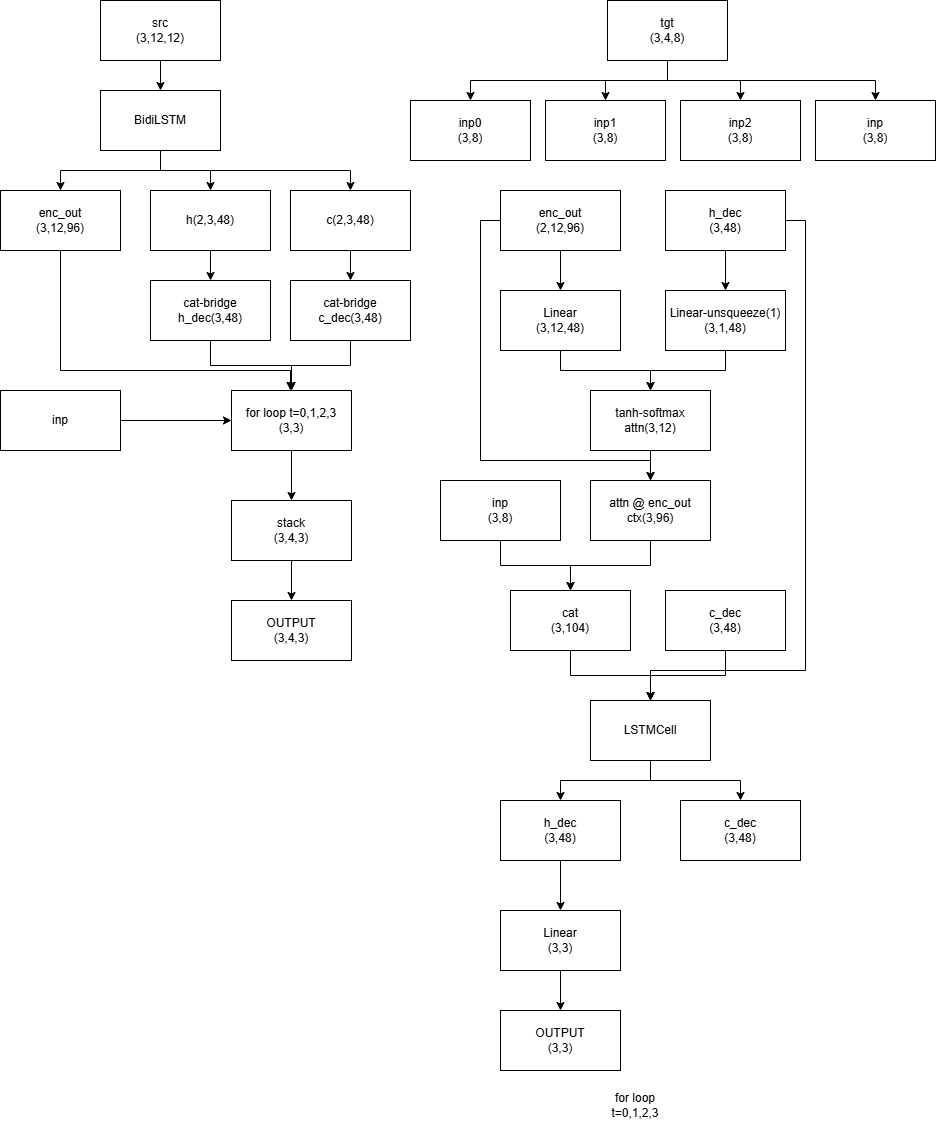

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class Seq2SeqAtt(nn.Module):
    def __init__(self,enc_in=12,dec_in=8,hidden=48,out_steps=4,out_dim=3):
        super().__init__()
        self.out_steps = out_steps
        self.enc = nn.LSTM(enc_in,hidden,batch_first=True,bidirectional=True)
        self.dec_cell = nn.LSTMCell(dec_in + hidden * 2,hidden)
        self.W1 = nn.Linear(hidden * 2,hidden ,bias=False)
        self.W2 = nn.Linear(hidden,hidden,bias=False)
        self.v = nn.Linear(hidden,1,bias=False)
        self.bridge_h = nn.Linear(hidden * 2,hidden)
        self.bridge_c = nn.Linear(hidden * 2,hidden)
        self.head = nn.Linear(hidden,out_dim)
    def forward(self,src,tgt):
        enc_out,(h,c) = self.enc(src)
        h_dec = self.bridge_h(torch.cat([h[-2],h[-1]],dim=1))
        c_dec = self.bridge_c(torch.cat([c[-2],c[-1]],dim=1))
        outputs = []
        for t in range(self.out_steps):
            inp = tgt[:,t]
            scores = self.v(torch.tanh(
                self.W1(enc_out) + self.W2(h_dec).unsqueeze(1)
            )).squeeze(-1)
            attn = F.softmax(scores,dim=-1)
            ctx = (attn.unsqueeze(1) @ enc_out).squeeze(1)
            h_dec,c_dec = self.dec_cell(torch.cat([inp,ctx],dim=1),(h_dec,c_dec))
            outputs.append(self.head(h_dec))
        return torch.stack(outputs,dim=1)
model = Seq2SeqAtt()
model.eval()
with torch.no_grad():
    out = model(torch.randn(3,12,12),torch.randn(3,4,8))
    print(out.shape)
from PIL import Image
import IPython.display as display
img = Image.open('Seq2SeqAtt.png')
display.display(img)